# Streaming Customer Segmentation using Unsupervised Learning

### Objective
The goal of this project is to segment users based on behavioral patterns using clustering techniques.

Since the dataset does not contain a churn label, unsupervised learning is used to group users and identify which segment appears more at risk based on engagement behavior.

### Approach
- Data Cleaning
- Feature Engineering
- Preprocessing using Pipelines
- Clustering (KMeans & Agglomerative)
- Model Evaluation using Silhouette Score
- Cluster Interpretation and Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/final/streaming_churn_dataset.csv"
)

df.shape

(50000, 37)

In [3]:
df.head()

,subscription_start_date,subscription_length_days,subscription_plan,monthly_price,billing_cycle,payment_method,total_watch_time_hours,sessions_count,avg_session_duration_minutes,days_since_last_watch,...,support_tickets_count,payment_failures_count,account_on_hold,used_free_trial,subscription_length_months,current_month,days_until_next_billing,genres_watched,devices_used,support_ticket_reasons
0,2022-11-07,785,basic,9.99,monthly,credit_card,74.963172,29.742333,152.370633,5.587050,...,0,0,0,0,26,12,7,Romance,"smart_tv, desktop",NaN
1,2023-02-28,672,standard,15.99,monthly,apple_pay,13.848148,8.341995,102.980411,5.350973,...,0,1,0,1,22,12,6,"Action, Sports, Kids, Romance, Reality",smart_tv,NaN
2,2024-01-31,335,standard,15.99,monthly,debit_card,43.368652,20.970448,120.414698,10.167759,...,0,0,0,0,11,12,6,"Anime, Kids","streaming_device, tablet",NaN
3,2021-05-21,1320,standard,15.99,monthly,credit_card,28.698510,13.858491,112.382035,20.525603,...,0,0,0,1,44,12,5,"Horror, Documentary, Sci-Fi, Drama, Kids, Roma...",smart_tv,NaN
4,2023-04-05,636,family,24.99,annual,credit_card,204.641244,95.626485,119.821246,6.219125,...,0,0,0,1,21,12,4,"Sci-Fi, Kids, Action",smart_tv,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   subscription_start_date       50000 non-null  object 
 1   subscription_length_days      50000 non-null  int64  
 2   subscription_plan             50000 non-null  object 
 3   monthly_price                 50000 non-null  float64
 4   billing_cycle                 50000 non-null  object 
 5   payment_method                50000 non-null  object 
 6   total_watch_time_hours        50000 non-null  float64
 7   sessions_count                50000 non-null  float64
 8   avg_session_duration_minutes  50000 non-null  float64
 9   days_since_last_watch         50000 non-null  float64
 10  unique_titles_watched         50000 non-null  float64
 11  content_completion_rate       50000 non-null  float64
 12  abandoned_series_count        50000 non-null  int64  
 13  b

In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
support_ticket_reasons,37571
genres_watched,2500
ratings_given_count,2500
reviews_written_count,2500
devices_used,2500
billing_cycle,0
monthly_price,0
subscription_plan,0
subscription_length_days,0
subscription_start_date,0


### Data Cleaning

Based on the initial data inspection and null value counts:

*   **Dropped Columns with High Missingness:** Columns such as `support_ticket_reasons`, `genres_watched`, and `devices_used` had a significant number of missing values (some over 75%). Given their nature, imputing these would be highly speculative and could introduce bias. Therefore, they were dropped to maintain data quality.
*   **Subscription Start Date:** The `subscription_start_date` column, while complete, was dropped as its direct date format is not suitable for clustering. Its temporal information is largely captured by `subscription_length_days` and `subscription_length_months`, which are already numerical features.

Missing values in other features (like `ratings_given_count` and `reviews_written_count`) will be handled by the `SimpleImputer` within the preprocessing pipeline, using the median strategy for numerical features and most frequent for categorical features.

In [6]:
drop_cols = [
    "subscription_start_date",
    "genres_watched",
    "devices_used",
    "support_ticket_reasons"
]

df = df.drop(columns=drop_cols)

### Feature Engineering

To better represent user behavior, several new features were created:

- **Engagement Score**: Combines watch time, completion rate, and sessions
- **Inactivity Flag**: Identifies users with low recent activity
- **Payment Risk**: Captures billing-related issues
- **Support Risk**: Indicates whether a user has raised support tickets
- **Abandonment Rate**: Measures how often users drop content midway

These features help improve clustering by capturing meaningful behavioral patterns.

In [7]:
df["engagement_score"] = (
    df["total_watch_time_hours"] *
    df["content_completion_rate"] *
    df["sessions_count"]
)

df["inactivity_flag"] = (df["days_since_last_watch"] > 14).astype(int)

df["payment_risk"] = (
    df["payment_failures_count"] + df["account_on_hold"]
)

df["support_risk"] = (df["support_tickets_count"] > 0).astype(int)

df["abandonment_rate"] = (
    df["abandoned_series_count"] / (df["unique_titles_watched"] + 1)
)

In [8]:
X = df.copy()

In [9]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

(['subscription_length_days',
  'monthly_price',
  'total_watch_time_hours',
  'sessions_count',
  'avg_session_duration_minutes',
  'days_since_last_watch',
  'unique_titles_watched',
  'content_completion_rate',
  'abandoned_series_count',
  'binge_sessions_count',
  'genres_watched_count',
  'new_content_ratio',
  'devices_used_count',
  'has_profile',
  'number_of_profiles',
  'watchlist_size',
  'ratings_given_count',
  'reviews_written_count',
  'downloads_count',
  'support_tickets_count',
  'payment_failures_count',
  'account_on_hold',
  'used_free_trial',
  'subscription_length_months',
  'current_month',
  'days_until_next_billing',
  'engagement_score',
  'inactivity_flag',
  'payment_risk',
  'support_risk',
  'abandonment_rate'],
 ['subscription_plan',
  'billing_cycle',
  'payment_method',
  'primary_genre',
  'content_type_preference',
  'primary_device',
  'primary_os'])

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [12]:
X_processed = preprocessor.fit_transform(X)

X_processed.shape

(50000, 72)

### Clustering Approach

Since the dataset is unlabeled, clustering is used to identify natural groupings.

KMeans was used as the primary model. Silhouette score was used to evaluate clustering quality instead of the elbow method, as it provides a more objective measure of cluster separation.

MiniBatch KMeans was also tested as a secondary model due to its efficiency on large datasets.

### Selecting the Number of Clusters

Since the dataset is unlabeled, We used silhouette score to compare different values of K. Silhouette score measures how well-separated the clusters are. A higher score indicates better-defined clusters.

In [13]:
sil_scores = []

k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.2574
K=3, Silhouette Score=0.0550
K=4, Silhouette Score=0.0629
K=5, Silhouette Score=0.0485
K=6, Silhouette Score=0.0656
K=7, Silhouette Score=0.0639


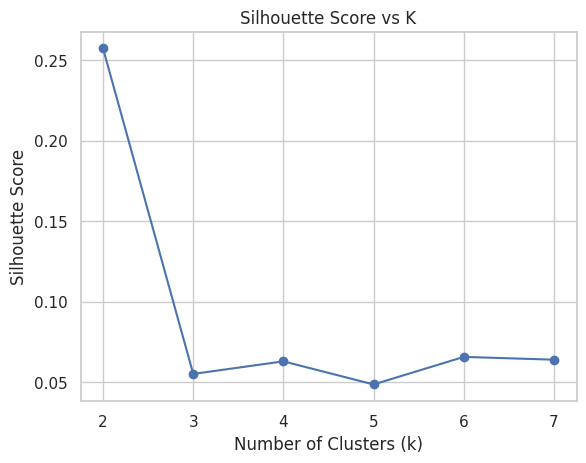

In [14]:
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

### Hyperparameter Tuning

Different values of K (2 to 7) were tested. The optimal value was selected based on silhouette score.

K=2 produced the highest silhouette score, indicating the best cluster separation.

This ensures that the model selection is data-driven rather than manually chosen.




### Cross-Validation Consideration

Traditional cross-validation is not applicable to clustering since there are no labels.

Instead, silhouette score was used across multiple values of K to evaluate model stability and performance.

In [15]:
from sklearn.cluster import MiniBatchKMeans

mini_kmeans = MiniBatchKMeans(
    n_clusters=2,
    random_state=42,
    batch_size=1024,
    n_init=10
)

mini_labels = mini_kmeans.fit_predict(X_processed)

sil_score_mini = silhouette_score(X_processed, mini_labels)

print("MiniBatch KMeans Silhouette Score:", round(sil_score_mini, 4))

MiniBatch KMeans Silhouette Score: 0.183


### Model Comparison

Two clustering models were tested:

- KMeans Silhouette Score: 0.2574
- MiniBatch KMeans Silhouette Score: 0.1830

KMeans produced better-separated clusters and was selected as the final model.

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_processed)

df["cluster"] = clusters

In [17]:
df["cluster"].value_counts()

,count
cluster,
0,46374
1,3626


In [18]:
cluster_summary = df.groupby("cluster").mean(numeric_only=True)
cluster_summary.T

cluster,0,1
subscription_length_days,912.446134,914.519029
monthly_price,16.450366,16.456078
total_watch_time_hours,16.605734,130.577781
sessions_count,8.239006,65.187392
avg_session_duration_minutes,113.207681,120.393206
days_since_last_watch,5.029072,5.028378
unique_titles_watched,5.491676,35.749782
content_completion_rate,0.397582,0.417613
abandoned_series_count,1.999224,2.005516
binge_sessions_count,0.801936,6.157198


In [24]:
print("Processed data shape:", X_processed.shape)
print("Cluster distribution:\n", df["cluster"].value_counts())

Processed data shape: (50000, 72)
Cluster distribution:
 cluster
0    46374
1     3626
Name: count, dtype: int64


### Cluster Visualization (PCA)

PCA was used to reduce the dataset to two dimensions for visualization.

This helps visually confirm that clusters are well separated.

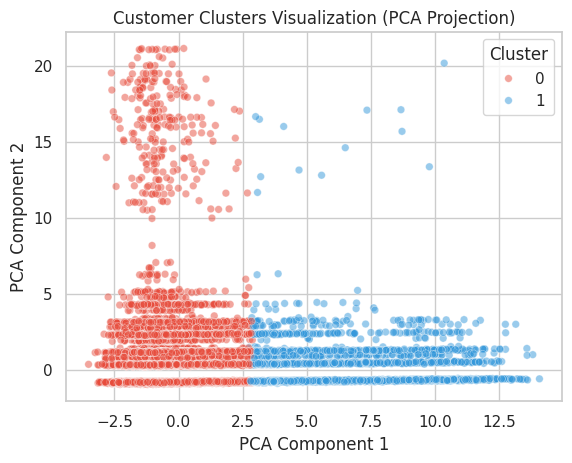

In [19]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

# Plot
sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette=["#e74c3c", "#3498db"],
    alpha=0.5,
    s=30
)

plt.title("Customer Clusters Visualization (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

### Cluster Analysis

To understand each cluster, average values of key features were compared. This helps identify behavioral differences between user groups.

In [20]:
important_features = [
    "total_watch_time_hours",
    "sessions_count",
    "days_since_last_watch",
    "engagement_score",
    "payment_risk",
    "abandonment_rate"
]

df.groupby("cluster")[important_features].mean()

,total_watch_time_hours,sessions_count,days_since_last_watch,engagement_score,payment_risk,abandonment_rate
cluster,,,,,,
0,16.605734,8.239006,5.029072,101.492979,0.246410,0.656002
1,130.577781,65.187392,5.028378,4001.795916,0.224214,0.094433


The large difference in engagement_score confirms that engagement is the strongest differentiator between clusters.

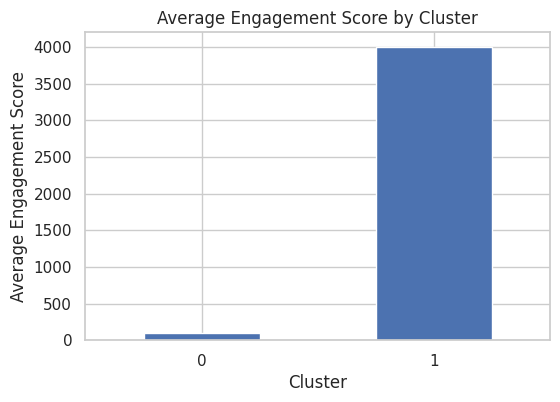

In [21]:
df.groupby("cluster")["engagement_score"].mean().plot(kind="bar", figsize=(6,4))
plt.title("Average Engagement Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=0)
plt.show()

Targeting Cluster 0 can have the highest business impact since it represents the majority of users.

### Cluster Interpretation

The clustering results reveal two clearly distinct behavioral groups:

- **Cluster 1 (High Engagement Users):**
  These users show significantly higher watch time, session counts, and engagement scores. They also have a very low abandonment rate, indicating consistent and meaningful interaction with the platform. This group represents loyal and high-value users.

- **Cluster 0 (Low Engagement Users):**
  These users exhibit low watch time, fewer sessions, and significantly higher abandonment rates. Despite similar recency (days since last watch), their overall interaction with the platform is minimal. This group represents passive users who are more likely to be at risk of churn.

The clustering effectively separates users based on engagement behavior, which is a strong indicator of customer retention without relying on labeled data.

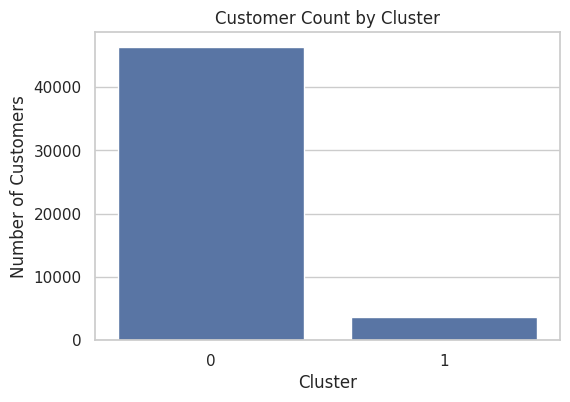

In [22]:
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title("Customer Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

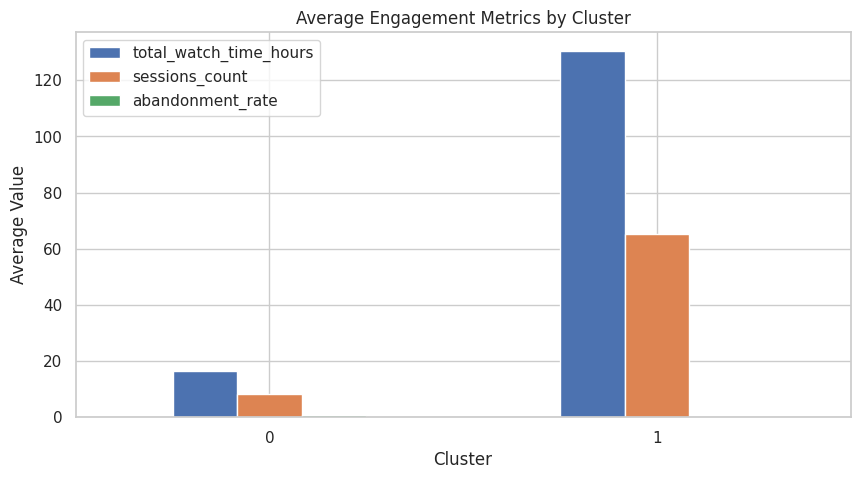

In [23]:
comparison_features = [
    "total_watch_time_hours",
    "sessions_count",
    "abandonment_rate"
]

cluster_compare = df.groupby("cluster")[comparison_features].mean()

cluster_compare.plot(kind="bar", figsize=(10,5))
plt.title("Average Engagement Metrics by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

### Business Recommendations

- Prioritize engagement strategies for Cluster 0 users, as they form the majority and show low interaction levels.
- Use personalized recommendations and notifications to increase platform activity.
- Reduce abandonment by improving content relevance and user experience.
- Retain Cluster 1 users by offering loyalty programs or premium features to maintain high engagement.

Focusing on improving engagement among low-activity users can significantly enhance retention and long-term customer value.

### Conclusion

Clustering successfully identified two distinct user segments based on engagement behavior.

The results show that engagement is a strong indicator of retention, even without labeled data.

This approach provides actionable insights for improving customer retention and long-term value.

Future work could include testing additional clustering methods or incorporating time-based behavior.

In [25]:
df = df.drop(columns=[col for col in drop_cols if col in df.columns])